Saving Student_performance_data _.csv to Student_performance_data _ (1).csv
Missing values in each column:
 Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64
Number of duplicate rows: 0

Cleaned Dataset Summary:
                age       gender    ethnicity  parentaleducation  \
count  2.392000e+03  2392.000000  2392.000000        2392.000000   
mean   8.406505e-16     0.510870     0.877508           1.746237   
std    1.000209e+00     0.499986     1.028476           1.000411   
min   -1.307132e+00     0.000000     0.000000           0.000000   
25%   -1.307132e+00     0.000000     0.000000           1.000000   
50%   -4.171064e-01     1.000000     0.000000           2.000000   
75%    4.729190e-01     1.0

<ipython-input-2-d7f776bf6b98>:176: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


GradientBoosting R2 score: 95.49%
GradientBoosting Mean Squared Error: 0.0373
GradientBoosting Mean Absolute Error: 0.1467
--------------------------------------------------
Training AdaBoost...
AdaBoost R2 score: 92.64%
AdaBoost Mean Squared Error: 0.0609
AdaBoost Mean Absolute Error: 0.1928
--------------------------------------------------
Training LinearRegression...
LinearRegression R2 score: 95.68%
LinearRegression Mean Squared Error: 0.0357
LinearRegression Mean Absolute Error: 0.1506
--------------------------------------------------
Training Ridge...
Ridge R2 score: 95.68%
Ridge Mean Squared Error: 0.0357
Ridge Mean Absolute Error: 0.1506
--------------------------------------------------
Training Lasso...
Lasso R2 score: 95.47%
Lasso Mean Squared Error: 0.0375
Lasso Mean Absolute Error: 0.1517
--------------------------------------------------
Training SVR...
SVR R2 score: 95.66%
SVR Mean Squared Error: 0.0359
SVR Mean Absolute Error: 0.1510
----------------------------------

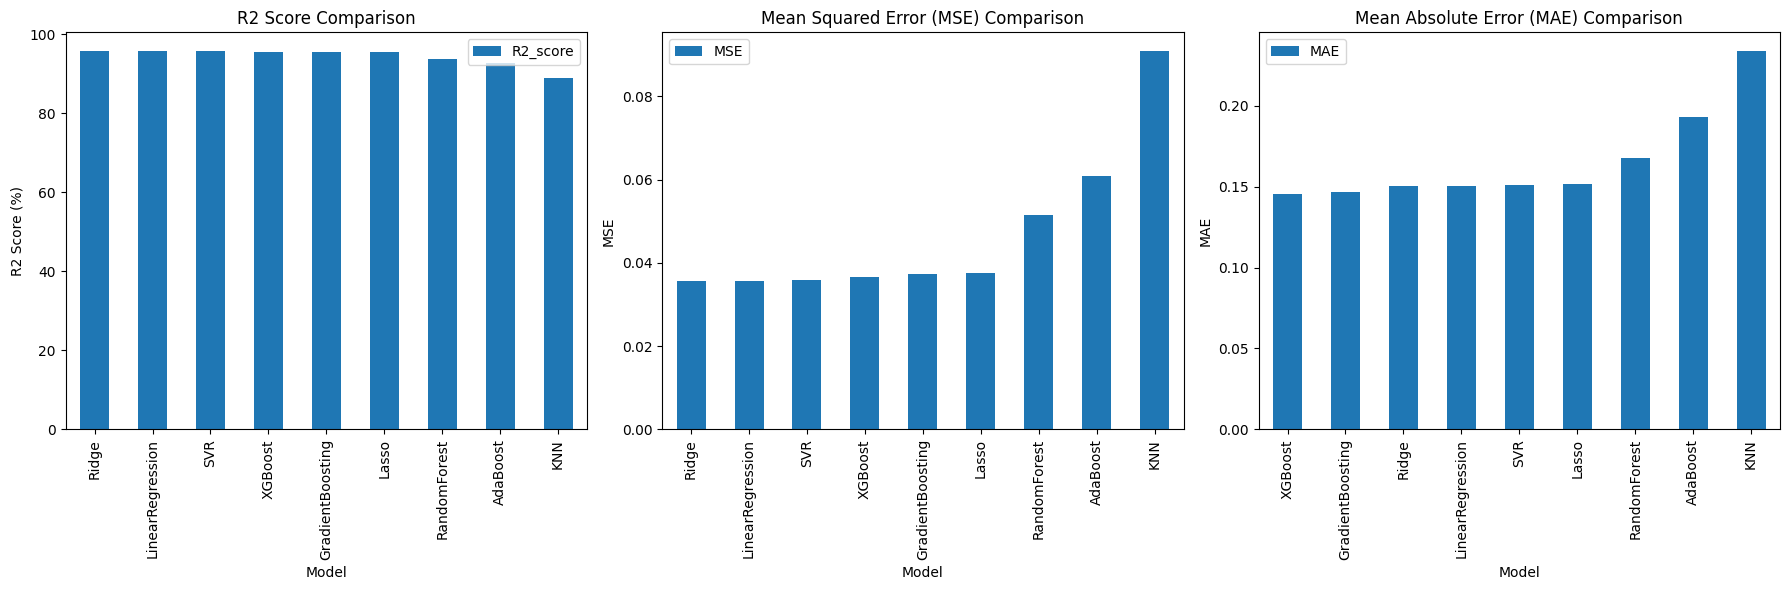

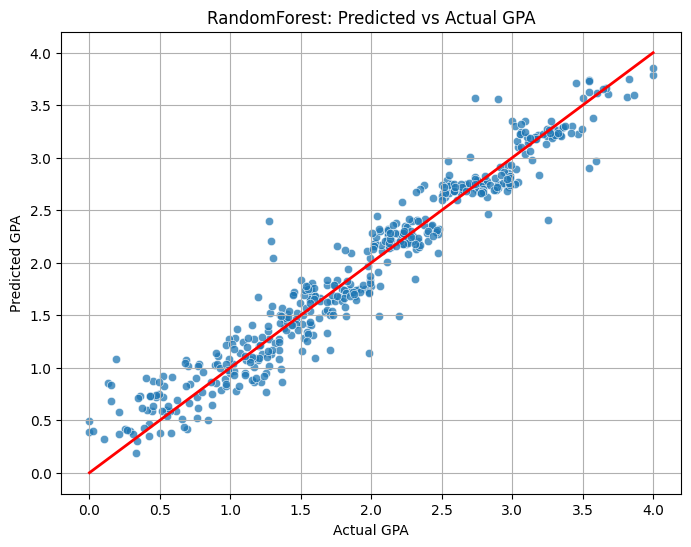

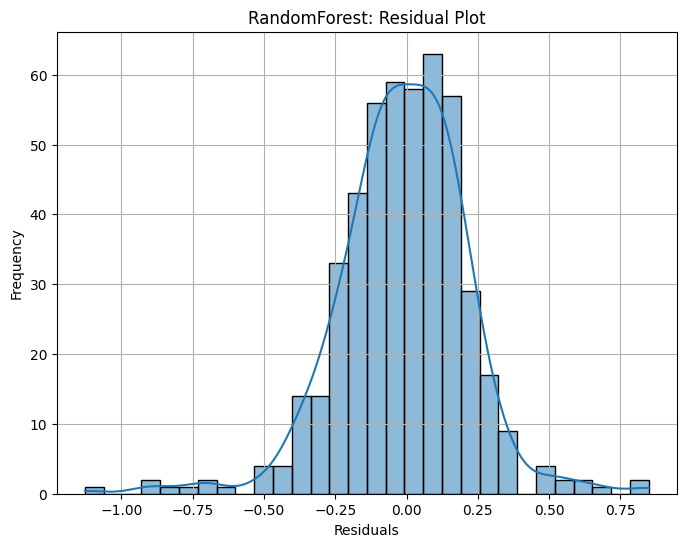

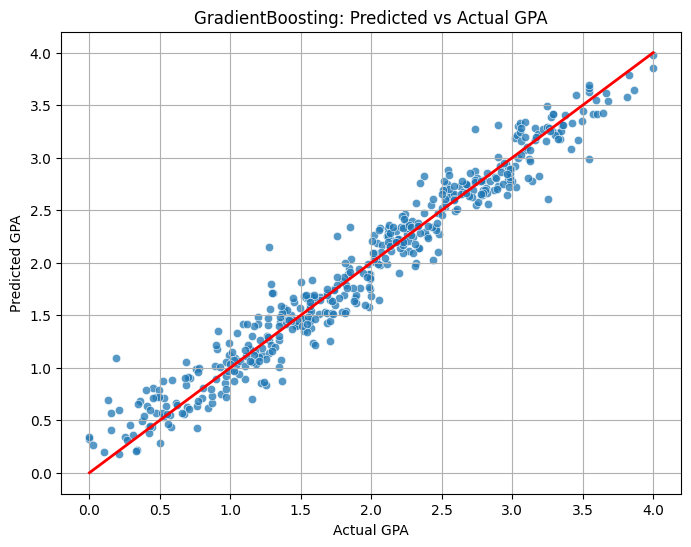

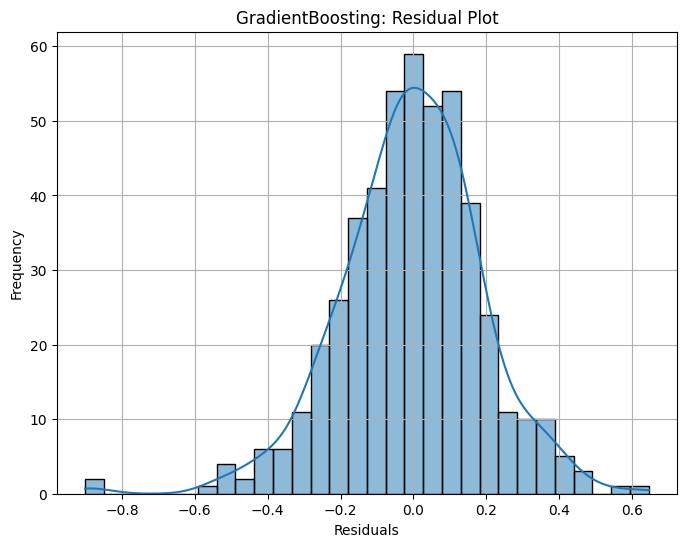

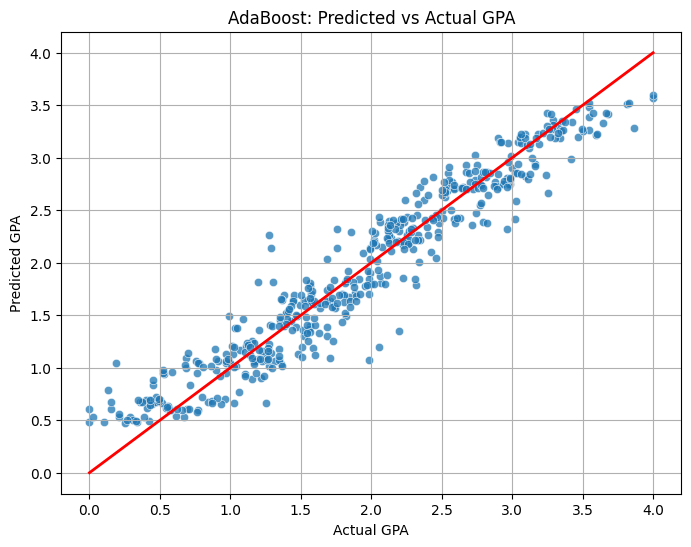

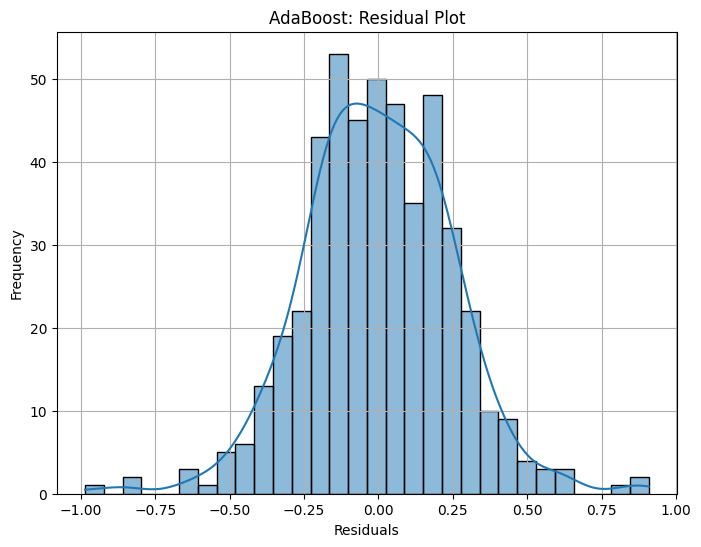

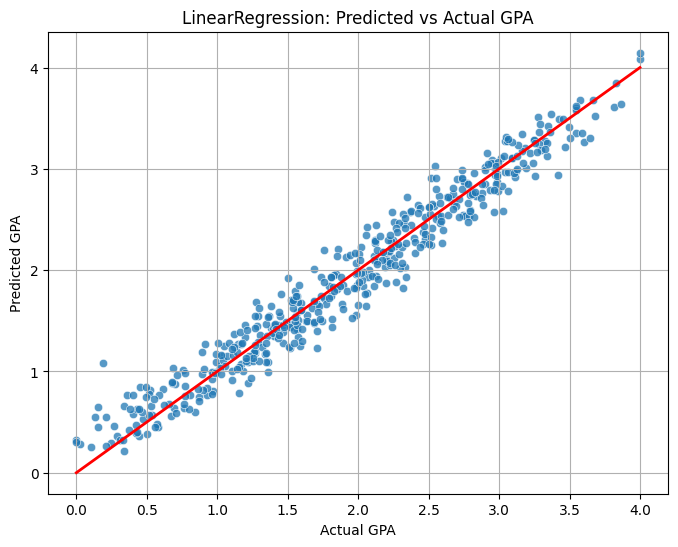

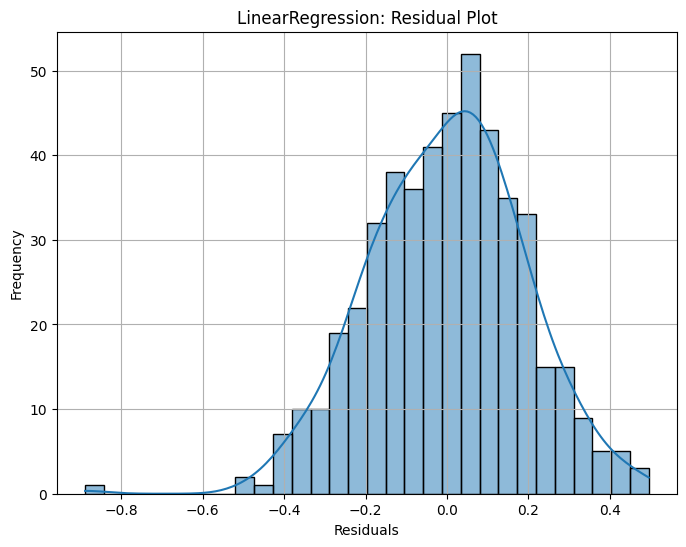

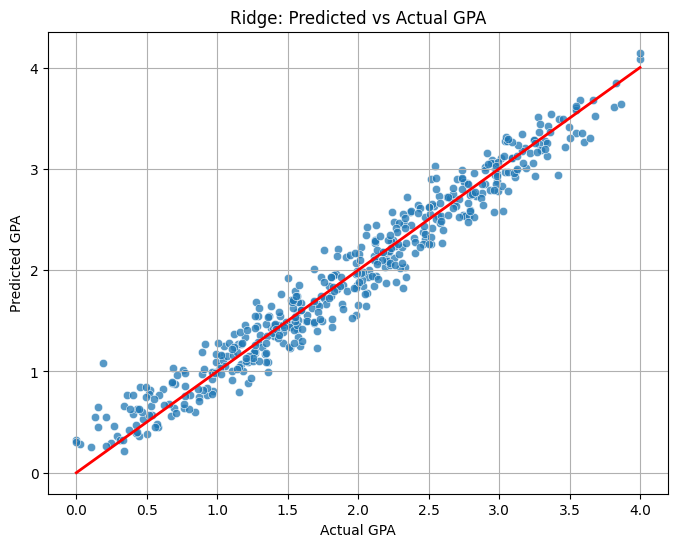

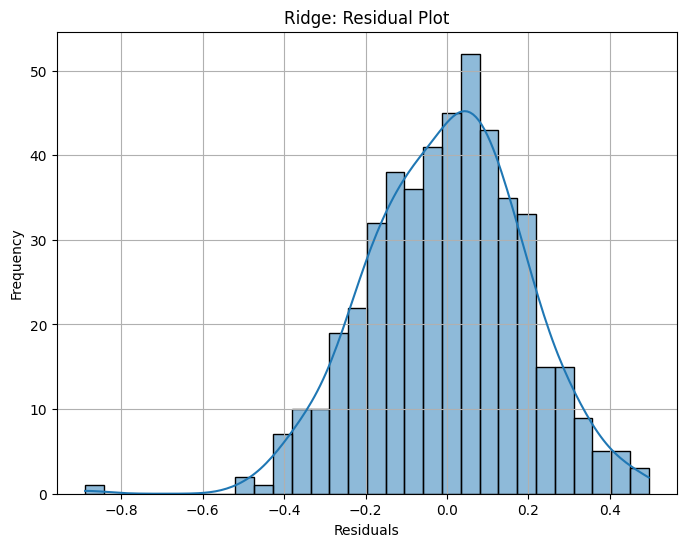

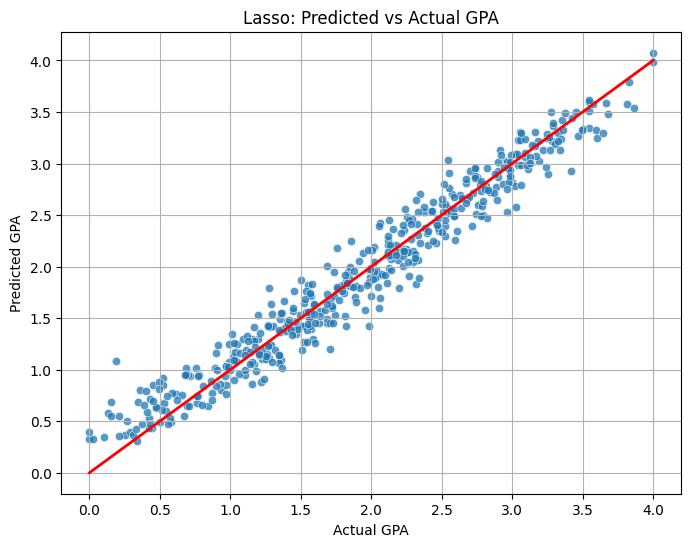

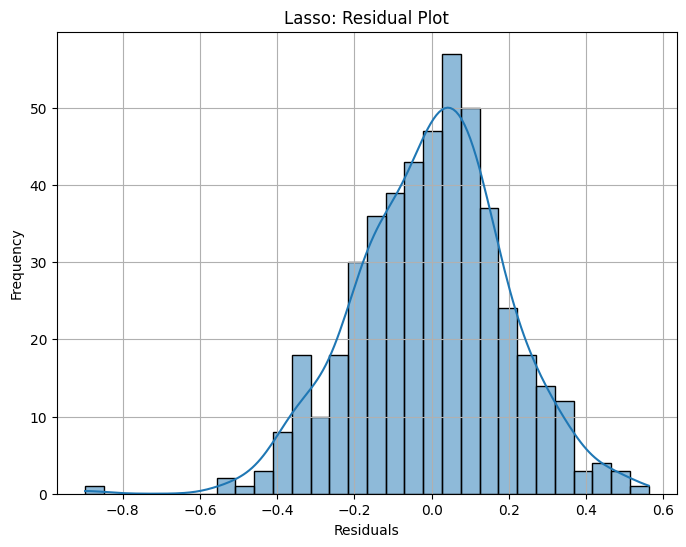

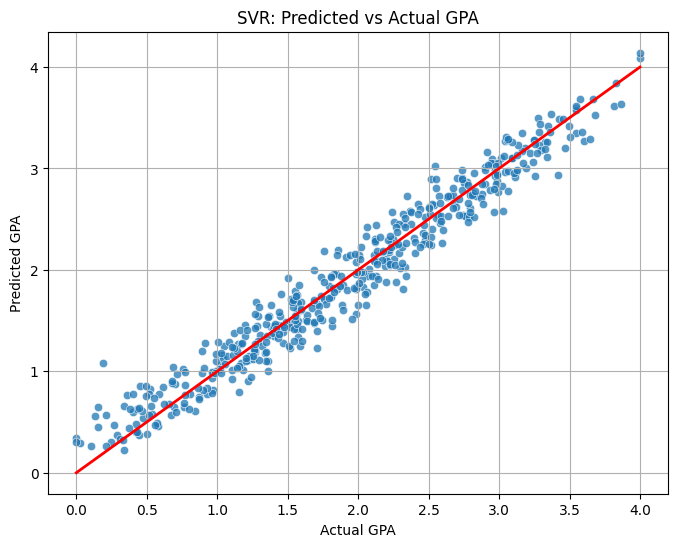

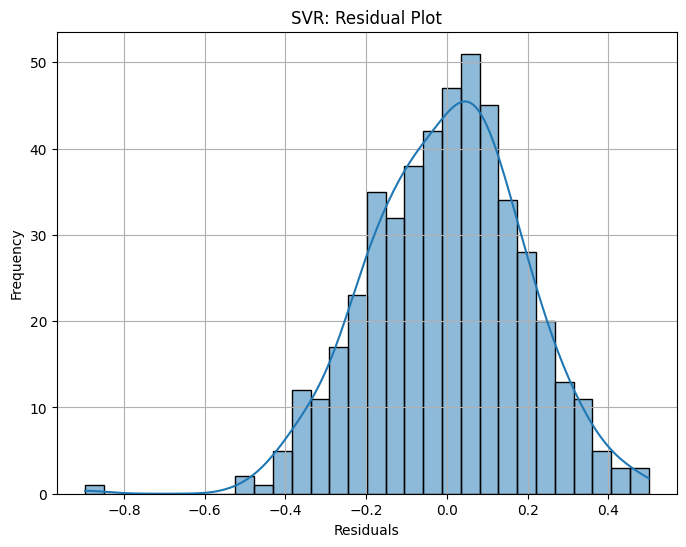

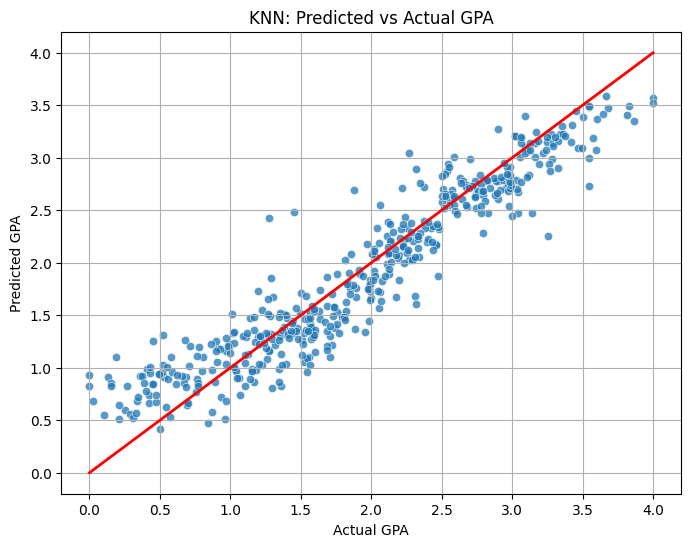

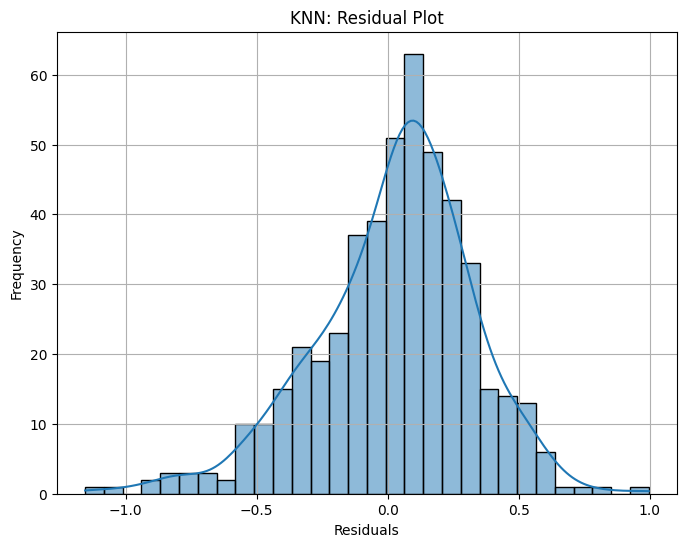

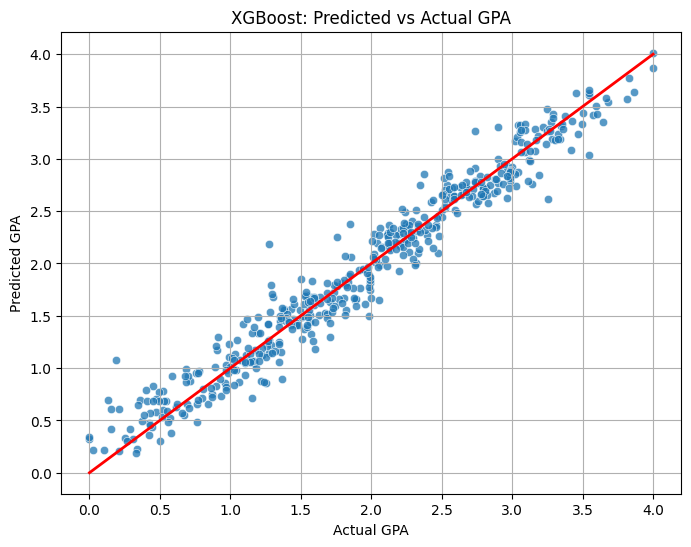

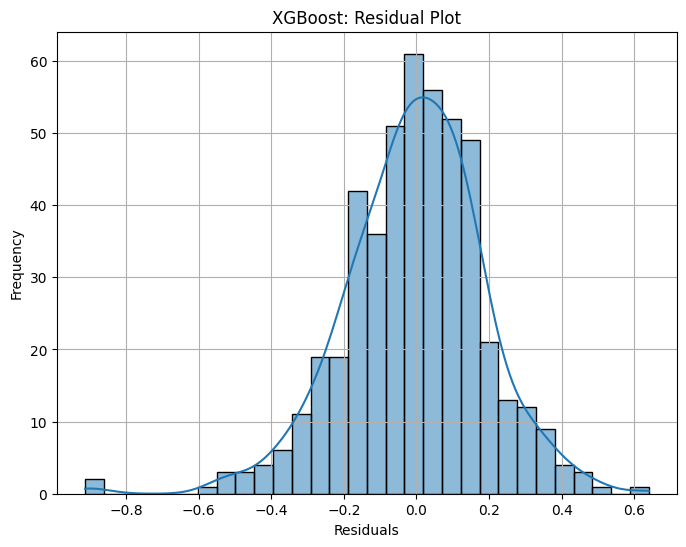


RandomForest Feature Importances:
              Feature  Importance
5            absences    0.754826
12         gradeclass    0.156615
4     studytimeweekly    0.035664
7     parentalsupport    0.017921
6            tutoring    0.007144
9              sports    0.005312
3   parentaleducation    0.004624
0                 age    0.004575
8     extracurricular    0.004401
2           ethnicity    0.003735
1              gender    0.001775
10              music    0.001758
11       volunteering    0.001652


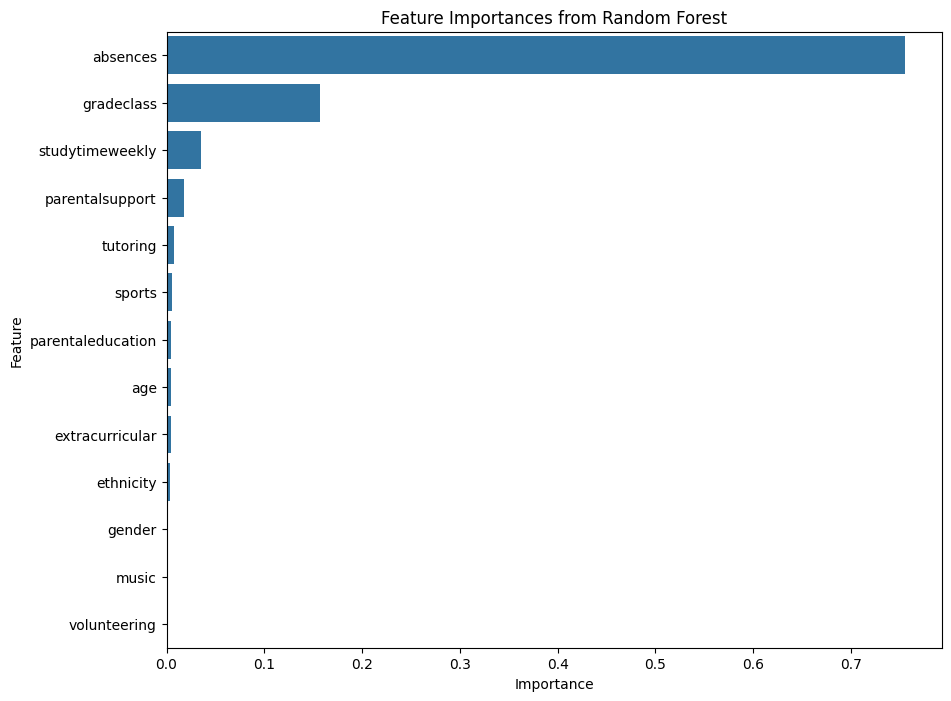


Ridge Regression Coefficients:
              Feature  Coefficient
6            tutoring     0.240978
8     extracurricular     0.177313
9              sports     0.176534
4     studytimeweekly     0.154297
10              music     0.146101
7     parentalsupport     0.139092
1              gender     0.013015
2           ethnicity     0.003505
3   parentaleducation     0.001167
11       volunteering     0.000242
0                 age    -0.006471
12         gradeclass    -0.061891
5            absences    -0.786554


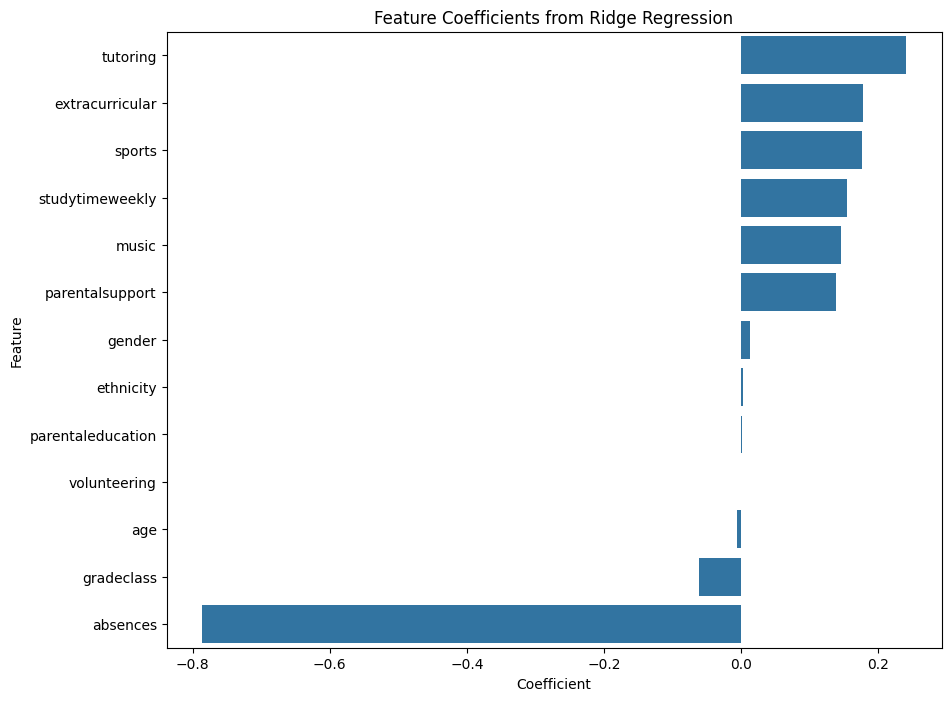

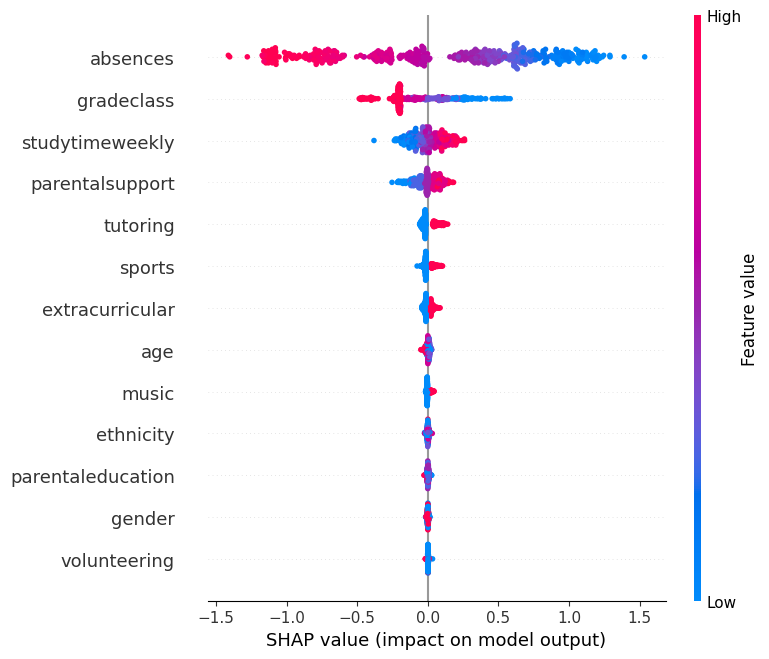

In [2]:
# Install shap if not already installed
!pip install shap

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import shap

# Load the data into a DataFrame
from google.colab import files
uploaded = files.upload()

# Assuming 'df' is the DataFrame loaded from the CSV file
df = pd.read_csv(list(uploaded.keys())[0])

# ---------------------------- DATA CLEANING ----------------------------

# Drop irrelevant columns
if 'StudentID' in df.columns:
    df.drop('StudentID', axis=1, inplace=True)

# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Drop rows with missing values (or you can fill them using fillna())
df = df.dropna()

# Check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Ensure the data types are correct for categorical features
cats = ["Gender", "Ethnicity", "ParentalEducation", "Tutoring", "ParentalSupport", "Extracurricular", "Sports", "Music", "Volunteering"]
le = LabelEncoder()

for cat in cats:
    if df[cat].dtype == 'object':
        df[cat] = le.fit_transform(df[cat].values)

# Rename columns to lower case and remove spaces (optional)
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Handle outliers using IQR (Interquartile Range)
nums = ["age", "studytimeweekly", "absences"]
Q1 = df[nums].quantile(0.25)
Q3 = df[nums].quantile(0.75)
IQR = Q3 - Q1

# Filter out outliers
df = df[~((df[nums] < (Q1 - 1.5 * IQR)) | (df[nums] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Feature scaling for numerical features
scaler = StandardScaler()
df[nums] = scaler.fit_transform(df[nums])

# Show summary of cleaned dataset
print("\nCleaned Dataset Summary:")
print(df.describe())

# ---------------------------- MODEL TRAINING ----------------------------

# Define features and target
X = df.drop(columns=["gpa"])
y = df["gpa"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models with hyperparameter grids
model_grids = {
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "param_grid": {
            "n_estimators": [100, 300, 500],
            "max_depth": [10, 20, None]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "param_grid": {
            "n_estimators": [100, 300],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    },
    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=42),
        "param_grid": {
            "n_estimators": [100, 300],
            "learning_rate": [0.01, 0.1]
        }
    },
    "LinearRegression": {
        "model": LinearRegression(),
        "param_grid": {}
    },
    "Ridge": {
        "model": Ridge(),
        "param_grid": {
            "alpha": [0.1, 1.0, 10.0]
        }
    },
    "Lasso": {
        "model": Lasso(),
        "param_grid": {
            "alpha": [0.01, 0.1, 1.0]
        }
    },
    "SVR": {
        "model": SVR(),
        "param_grid": {
            "C": [0.1, 1.0, 10.0],
            "kernel": ['linear', 'rbf']
        }
    },
    "KNN": {
        "model": KNeighborsRegressor(),
        "param_grid": {
            "n_neighbors": [3, 5, 7],
            "weights": ['uniform', 'distance']
        }
    },
    "XGBoost": {
        "model": xgb.XGBRegressor(random_state=42),
        "param_grid": {
            "n_estimators": [100, 300],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    }
}

# Initialize dataframe to store results
results = pd.DataFrame(columns=['Model', 'R2_score', 'MSE', 'MAE'])

# Dictionary to store best parameters for each model
best_params_per_model = {}

# Train and evaluate each model with GridSearchCV
for name, config in model_grids.items():
    print(f"Training {name}...")
    grid_search = GridSearchCV(config["model"], config["param_grid"], cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Save best parameters for this model
    best_params_per_model[name] = grid_search.best_params_

    # Calculate evaluation metrics
    r2 = r2_score(y_test, y_pred) * 100
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"{name} R2 score: {r2:.2f}%")
    print(f"{name} Mean Squared Error: {mse:.4f}")
    print(f"{name} Mean Absolute Error: {mae:.4f}")
    print("-" * 50)

    # Only append the row if the results are valid (not empty or NaN)
    if not pd.isna(r2) and not pd.isna(mse) and not pd.isna(mae):
        new_row = pd.DataFrame({"Model": [name], "R2_score": [r2], "MSE": [mse], "MAE": [mae]})
        results = pd.concat([results, new_row], ignore_index=True)

# Sort and display results
results = results.sort_values(by="R2_score", ascending=False)
print("\nModel Comparison:")
print(results)

# ---------------------------- PLOTTING ----------------------------

# Plot the results for visual comparison with high DPI
fig, axes = plt.subplots(ncols=3, figsize=(18, 6), dpi=100)

# R2 Score plot
results.sort_values(by="R2_score", ascending=False).plot(x="Model", y="R2_score", kind="bar", ax=axes[0])
axes[0].set_title("R2 Score Comparison")
axes[0].set_ylabel("R2 Score (%)")


# MSE plot
results.sort_values(by="MSE", ascending=True).plot(x="Model", y="MSE", kind="bar", ax=axes[1])
axes[1].set_title("Mean Squared Error (MSE) Comparison")
axes[1].set_ylabel("MSE")

# MAE plot
results.sort_values(by="MAE", ascending=True).plot(x="Model", y="MAE", kind="bar", ax=axes[2])
axes[2].set_title("Mean Absolute Error (MAE) Comparison")
axes[2].set_ylabel("MAE")

plt.tight_layout()
plt.show()

# Plot the actual vs predicted GPA values for each model
for name, config in model_grids.items():
    best_model = GridSearchCV(config["model"], config["param_grid"], cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    # Scatter plot of Actual vs Predicted values with high DPI
    plt.figure(figsize=(8, 6), dpi=100)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.75)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
    plt.title(f'{name}: Predicted vs Actual GPA')
    plt.xlabel('Actual GPA')
    plt.ylabel('Predicted GPA')
    plt.grid(True)
    plt.show()

    # Residual plot with high DPI
    residuals = y_test - y_pred
    plt.figure(figsize=(8, 6), dpi=100)
    sns.histplot(residuals, kde=True, bins=30)
    plt.title(f'{name}: Residual Plot')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# ---------------------------- FEATURE IMPORTANCE ----------------------------

# For RandomForest with high DPI
best_rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
importances = best_rf.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nRandomForest Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 8), dpi=100)
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Random Forest')
plt.show()

# For Ridge Regression with high DPI
best_ridge = Ridge(alpha=1.0).fit(X_train, y_train)
coefficients = best_ridge.coef_
coefficients_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients}).sort_values(by='Coefficient', ascending=False)

print("\nRidge Regression Coefficients:")
print(coefficients_df)

plt.figure(figsize=(10, 8), dpi=100)
sns.barplot(x='Coefficient', y='Feature', data=coefficients_df)
plt.title('Feature Coefficients from Ridge Regression')
plt.show()

# For SHAP Explainer on XGBoost with high DPI
explainer = shap.Explainer(best_rf)
shap_values = explainer(X_test)

# Plot summary plot
plt.figure(dpi=100)
shap.summary_plot(shap_values, X_test)
